# Baseline Forecasting and Model Development

Evaluate a seasonal-naive baseline and Gradient Boosting model using a chronological 8-week validation window.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [3]:
def find_project_root():
    path = Path.cwd().resolve()

    for candidate in [path, *path.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate

    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [4]:
model_data = pd.read_csv(
    PROCESSED_DIR / "store_week_features.csv"
)

model_data["Date"] = pd.to_datetime(
    model_data["Date"]
)

model_data = (
    model_data
    .sort_values(["Store", "Date"])
    .reset_index(drop=True)
)

## Dataset Validation

In [6]:
assert len(model_data) == 4095
assert model_data["Store"].nunique() == 45
assert not model_data.duplicated(
    ["Store", "Date"]
).any()

print("Rows:", len(model_data))
print("Stores:", model_data["Store"].nunique())
print(
    "Date range:",
    model_data["Date"].min().date(),
    "to",
    model_data["Date"].max().date()
)

Rows: 4095
Stores: 45
Date range: 2011-02-04 to 2012-10-26


## Chronological Validation

- Development period: through 2012-07-27
- Validation period: 2012-08-03 to 2012-09-21
- Validation horizon: 8 weeks
- Final holdout: 2012-09-28 onward

The final holdout is not used for model selection.

In [8]:
validation_start = pd.Timestamp("2012-08-03")
validation_end = pd.Timestamp("2012-09-21")

development_data = model_data[
    model_data["Date"] < validation_start
].copy()

validation_data = model_data[
    model_data["Date"].between(
        validation_start,
        validation_end
    )
].copy()

In [9]:
assert (
    development_data["Date"].max()
    < validation_data["Date"].min()
)

assert validation_data["Date"].nunique() == 8

assert not set(
    development_data["Date"]
).intersection(
    validation_data["Date"]
)

print(
    "Development:",
    development_data["Date"].min().date(),
    "to",
    development_data["Date"].max().date()
)

print(
    "Validation:",
    validation_data["Date"].min().date(),
    "to",
    validation_data["Date"].max().date()
)

Development: 2011-02-04 to 2012-07-27
Validation: 2012-08-03 to 2012-09-21


## Forecast Evaluation

WAPE is used alongside MAE and RMSE.

\[
WAPE = \frac{\sum |Actual - Forecast|}
{\sum |Actual|}
\]

In [11]:
def wape(actual, forecast):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(actual - forecast).sum()
        / denominator
    )

In [12]:
def evaluate_forecast(actual, forecast):
    return {
        "MAE": mean_absolute_error(
            actual,
            forecast
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                forecast
            )
        ),
        "WAPE": wape(
            actual,
            forecast
        )
    }

In [13]:
test_actual = np.array([100, 200, 300])
test_forecast = np.array([90, 220, 270])

metrics_test = evaluate_forecast(
    test_actual,
    test_forecast
)

assert np.isclose(
    metrics_test["WAPE"],
    60 / 600
)

print("Metric validation passed.")

Metric validation passed.


## Seasonal-Naive Baseline

Forecast each store using sales from approximately the same week one year earlier.

\[
\hat{y}_{t} = y_{t-52}
\]

In [15]:
def seasonal_naive_forecast(
    history,
    forecast_dates
):
    history = (
        history
        .sort_values(["Store", "Date"])
        .copy()
    )

    forecasts = []

    for store_id in history["Store"].unique():

        store_history = history[
            history["Store"] == store_id
        ].set_index("Date")["Weekly_Sales"]

        for date in forecast_dates:

            lag_date = date - pd.Timedelta(
                weeks=52
            )

            forecasts.append({
                "Store": store_id,
                "Date": date,
                "Forecast": store_history.get(
                    lag_date,
                    np.nan
                )
            })

    return pd.DataFrame(forecasts)

In [16]:
validation_dates = (
    validation_data["Date"]
    .sort_values()
    .unique()
)

baseline_forecast = seasonal_naive_forecast(
    development_data,
    validation_dates
)

In [17]:
baseline_forecast = baseline_forecast.merge(
    validation_data[
        ["Store", "Date", "Weekly_Sales"]
    ],
    on=["Store", "Date"],
    how="left",
    validate="one_to_one"
)

assert len(baseline_forecast) == (
    45 * 8
)

assert baseline_forecast["Forecast"].notna().all()

In [18]:
baseline_metrics = evaluate_forecast(
    baseline_forecast["Weekly_Sales"],
    baseline_forecast["Forecast"]
)

baseline_metrics

{'MAE': 55469.12652777779,
 'RMSE': np.float64(89703.61391440417),
 'WAPE': np.float64(0.053426825176868545)}

### Baseline Interpretation

The seasonal-naive model provides a simple year-over-year benchmark.

The Gradient Boosting model should demonstrate whether recent demand, calendar information, and store characteristics improve on this benchmark.

## Gradient Boosting Model

The model uses:

- Historical sales lags
- Recent rolling statistics
- Calendar variables
- Holiday information
- Store type and size

Predictions are generated recursively across the 8-week horizon.

In [21]:
target = "Weekly_Sales"

numeric_features = [
    "lag_1",
    "lag_2",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "WeekOfYear",
    "Month",
    "Size"
]

categorical_features = [
    "HolidayName",
    "Type"
]

model_features = (
    numeric_features
    + categorical_features
)

for col in categorical_features:
    development_data[col] = (
        development_data[col]
        .fillna("None")
        .astype(str)
    )

    validation_data[col] = (
        validation_data[col]
        .fillna("None")
        .astype(str)
    )

assert not development_data[categorical_features].isna().any().any()
assert not validation_data[categorical_features].isna().any().any()

print("Feature types standardized.")

Feature types standardized.


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [23]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

In [24]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gbr_model)
    ]
)

## Recursive Forecasting Logic

For each future week:

1. Build lag and rolling features from the available history.
2. Predict the current week.
3. Add the prediction to the history.
4. Use that prediction when constructing the next week's features.

No future actual sales are used.

In [26]:
def recursive_forecast(
    model,
    history,
    future_calendar,
    feature_columns
):
    history = (
        history[
            ["Store", "Date", "Weekly_Sales"]
        ]
        .copy()
        .sort_values(["Store", "Date"])
    )

    future_calendar = (
        future_calendar
        .copy()
        .sort_values(["Date", "Store"])
    )

    store_ids = sorted(history["Store"].unique())
    predictions = []

    for date in sorted(
        future_calendar["Date"].unique()
    ):

        current_calendar = future_calendar[
            future_calendar["Date"] == date
        ].copy()

        assert len(current_calendar) == len(store_ids)
        assert current_calendar["Store"].nunique() == len(store_ids)
        assert set(current_calendar["Store"]) == set(store_ids)

        rows = []

        for store_id in store_ids:

            store_history = (
                history[
                    history["Store"] == store_id
                ]
                .sort_values("Date")
                .reset_index(drop=True)
            )

            sales = store_history["Weekly_Sales"]

            assert len(sales) >= 52

            row_calendar = current_calendar[
                current_calendar["Store"] == store_id
            ].iloc[0]

            row = {
                "Store": store_id,
                "Date": date,
                "lag_1": sales.iloc[-1],
                "lag_2": sales.iloc[-2],
                "lag_52": sales.iloc[-52],
                "rolling_mean_4": sales.iloc[-4:].mean(),
                "rolling_std_4": sales.iloc[-4:].std(),
                "WeekOfYear": row_calendar["WeekOfYear"],
                "Month": row_calendar["Month"],
                "HolidayName": row_calendar["HolidayName"],
                "Type": row_calendar["Type"],
                "Size": row_calendar["Size"]
            }

            rows.append(row)

        feature_frame = pd.DataFrame(rows)

        for col in ["HolidayName", "Type"]:
            feature_frame[col] = (
                feature_frame[col]
                .fillna("None")
                .astype(str)
            )

        forecast_values = model.predict(
            feature_frame[feature_columns]
        )

        for row, prediction in zip(
            rows,
            forecast_values
        ):
            predictions.append({
                "Store": row["Store"],
                "Date": date,
                "Forecast": prediction
            })

            history = pd.concat(
                [
                    history,
                    pd.DataFrame([{
                        "Store": row["Store"],
                        "Date": date,
                        "Weekly_Sales": prediction
                    }])
                ],
                ignore_index=True
            )

    return pd.DataFrame(predictions)

In [27]:
X_development = development_data[
    model_features
]

y_development = development_data[
    target
]

model.fit(
    X_development,
    y_development
)

print("Gradient Boosting model fitted.")

Gradient Boosting model fitted.


In [28]:
future_calendar = validation_data[
    [
        "Store",
        "Date",
        "WeekOfYear",
        "Month",
        "HolidayName",
        "Type",
        "Size"
    ]
].copy()

assert len(future_calendar) == 45 * 8
assert future_calendar["Store"].nunique() == 45
assert future_calendar["Date"].nunique() == 8
assert not future_calendar.duplicated(
    ["Store", "Date"]
).any()

for col in ["HolidayName", "Type"]:
    future_calendar[col] = (
        future_calendar[col]
        .fillna("None")
        .astype(str)
    )

print("Future calendar validated.")

Future calendar validated.


In [29]:
gbr_forecast = recursive_forecast(
    model=model,
    history=development_data,
    future_calendar=future_calendar,
    feature_columns=model_features
)

In [30]:
assert len(gbr_forecast) == 45 * 8

assert not gbr_forecast.duplicated(
    ["Store", "Date"]
).any()

assert (
    gbr_forecast["Date"].min()
    == validation_dates.min()
)

assert (
    gbr_forecast["Date"].max()
    == validation_dates.max()
)

print("Recursive forecast validated.")

Recursive forecast validated.


In [31]:
gbr_evaluation = gbr_forecast.merge(
    validation_data[
        ["Store", "Date", "Weekly_Sales"]
    ],
    on=["Store", "Date"],
    how="left",
    validate="one_to_one"
)

assert (
    gbr_evaluation["Weekly_Sales"]
    .notna()
    .all()
)

In [32]:
gbr_metrics = evaluate_forecast(
    gbr_evaluation["Weekly_Sales"],
    gbr_evaluation["Forecast"]
)

gbr_metrics

{'MAE': 41160.07262595763,
 'RMSE': np.float64(68835.74144808014),
 'WAPE': np.float64(0.03964461209521681)}

In [33]:
comparison = pd.DataFrame(
    {
        "Seasonal Naive": baseline_metrics,
        "Gradient Boosting": gbr_metrics
    }
).T

comparison

,MAE,RMSE,WAPE
Seasonal Naive,55469.126528,89703.613914,0.053427
Gradient Boosting,41160.072626,68835.741448,0.039645


## Model Comparison

The comparison uses the same 8-week validation horizon for both models.

WAPE is the primary business-oriented metric because it expresses total absolute forecast error relative to total actual sales.

In [35]:
wape_improvement = (
    (
        baseline_metrics["WAPE"]
        - gbr_metrics["WAPE"]
    )
    / baseline_metrics["WAPE"]
)

print(
    f"WAPE improvement: "
    f"{wape_improvement:.1%}"
)

WAPE improvement: 25.8%


## Forecast vs Actual

In [37]:
validation_plot = (
    gbr_evaluation
    .groupby("Date")[
        ["Weekly_Sales", "Forecast"]
    ]
    .sum()
)

validation_plot

,Weekly_Sales,Forecast
Date,,
2012-08-03,47485899.56,4.728894e+07
2012-08-10,47403451.04,4.656243e+07
2012-08-17,47354452.05,4.696126e+07
2012-08-24,47447323.60,4.770216e+07
2012-08-31,47159639.43,4.628042e+07
2012-09-07,48330059.31,4.774237e+07
2012-09-14,44226038.65,4.523297e+07
2012-09-21,44354547.11,4.421492e+07


In [38]:
print(
    validation_plot
)

            Weekly_Sales      Forecast
Date                                  
2012-08-03   47485899.56  4.728894e+07
2012-08-10   47403451.04  4.656243e+07
2012-08-17   47354452.05  4.696126e+07
2012-08-24   47447323.60  4.770216e+07
2012-08-31   47159639.43  4.628042e+07
2012-09-07   48330059.31  4.774237e+07
2012-09-14   44226038.65  4.523297e+07
2012-09-21   44354547.11  4.421492e+07


## Feature Importance

Feature importance is used for interpretation, not as evidence that the model generalizes well.

In [40]:
feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    model.named_steps["model"]
    .feature_importances_
)

feature_importance = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": importances
        }
    )
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
2,numeric__lag_52,0.797034
3,numeric__rolling_mean_4,0.174440
0,numeric__lag_1,0.017617
5,numeric__WeekOfYear,0.002943
1,numeric__lag_2,0.002726
7,numeric__Size,0.002319
4,numeric__rolling_std_4,0.001457
6,numeric__Month,0.000778
10,categorical__HolidayName_None,0.000326
12,categorical__HolidayName_Thanksgiving,0.000205


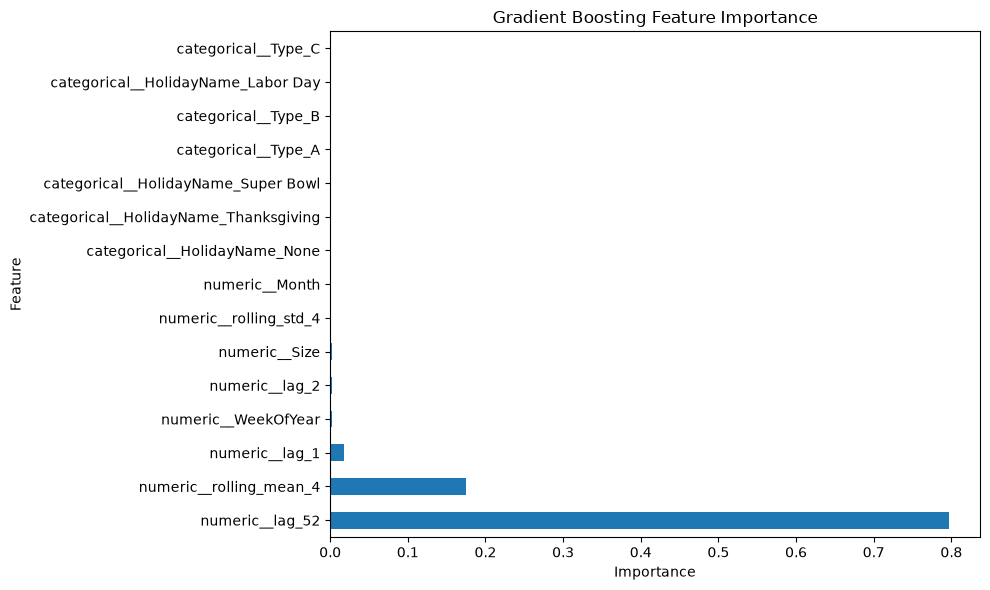

In [41]:
feature_importance.head(15).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Validation Summary

- Seasonal Naive provides the year-over-year benchmark.
- Gradient Boosting uses recent demand, annual seasonality, holiday information, and store attributes.
- The validation horizon is eight weeks.
- Forecasting is recursive to match the intended future forecasting process.
- Future actual sales are not used to construct recursive predictions.
- The final holdout remains separate from this model-development evaluation.

In [43]:
results_summary = pd.DataFrame(
    {
        "Model": [
            "Seasonal Naive",
            "Gradient Boosting"
        ],
        "MAE": [
            baseline_metrics["MAE"],
            gbr_metrics["MAE"]
        ],
        "RMSE": [
            baseline_metrics["RMSE"],
            gbr_metrics["RMSE"]
        ],
        "WAPE": [
            baseline_metrics["WAPE"],
            gbr_metrics["WAPE"]
        ]
    }
)

results_summary

,Model,MAE,RMSE,WAPE
0,Seasonal Naive,55469.126528,89703.613914,0.053427
1,Gradient Boosting,41160.072626,68835.741448,0.039645


## Model Selection

The selected development model is the model with the lower validation WAPE, subject to consistent performance in rolling backtesting.

Rolling backtesting and controlled feature-set comparison are handled in:

`06_backtesting_and_model_comparison.ipynb`